# 02 - Clustering y Reasignación de Unknown

## Clustering y Reasignación de Modelos `Unknown`

**Problema:** El 30.5% del dataset tiene `pricing_tier = Unknown`, lo que imposibilita el entrenamiento supervisado directo.  
**Solución:** Aplicar K-Means para descubrir arquetipos técnicos naturales y reasignar los Unknown por similitud técnica.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
np.random.seed(42)
print(' Librerías cargadas')

✓ Librerías cargadas


## Preparación del Dataset

Se carga el dataset original (453 modelos) y se aplica el pipeline de limpieza:
- Eliminación de modelos sin benchmarks críticos → **448 modelos válidos**
- Asignación de costo 0 a modelos open source
- Imputación de nulos por mediana del proveedor
- Construcción de features derivadas de valor/precio

In [ ]:
df = pd.read_csv('../datos/llm_price_performance_tracker_2026-03-31.csv')
df_limpio = df.dropna(subset=['aa_intelligence_index', 'aa_coding_index'], how='all').copy()

df_limpio.loc[df_limpio['is_open_source'] == True, 'input_cost_usd_per_1m'] = \
    df_limpio.loc[df_limpio['is_open_source'] == True, 'input_cost_usd_per_1m'].fillna(0)
df_limpio.loc[df_limpio['is_open_source'] == True, 'output_cost_usd_per_1m'] = \
    df_limpio.loc[df_limpio['is_open_source'] == True, 'output_cost_usd_per_1m'].fillna(0)

columnas = ['aa_intelligence_index', 'aa_coding_index', 'aa_math_index',
            'input_cost_usd_per_1m', 'output_cost_usd_per_1m',
            'output_tokens_per_second', 'time_to_first_token_s',
            'chatbot_arena_elo', 'release_year']

for col in columnas:
    if col in df_limpio.columns:
        df_limpio[col] = df_limpio.groupby('provider')[col].transform(lambda x: x.fillna(x.median()))
        df_limpio[col] = df_limpio[col].fillna(df_limpio[col].median())

df_limpio['costo_promedio'] = (df_limpio['input_cost_usd_per_1m'] + df_limpio['output_cost_usd_per_1m']) / 2
df_limpio['inteligencia_por_dolar'] = df_limpio['aa_intelligence_index'] / (df_limpio['costo_promedio'] + 0.001)
df_limpio['velocidad_por_dolar'] = df_limpio['output_tokens_per_second'] / (df_limpio['costo_promedio'] + 0.001)
df_limpio['promedio_benchmarks'] = (df_limpio['aa_intelligence_index'] + df_limpio['aa_coding_index'] + df_limpio['aa_math_index']) / 3
df_limpio['ratio_valor_general'] = df_limpio['promedio_benchmarks'] / (df_limpio['costo_promedio'] + 0.001)

print(f' Dataset: {df_limpio.shape[0]} modelos')

✓ Dataset: 448 modelos


## K-Means: Selección del Número Óptimo de Clusters

Se evalúa el **Silhouette Score** para valores de k entre 2 y 9, seleccionando el k que maximiza la separación y cohesión de los clusters.

**Features usadas para el clustering:**

| Feature | Descripción |
|---------|-------------|
| `aa_intelligence_index` | Índice de inteligencia general |
| `aa_coding_index` | Capacidad de programación |
| `aa_math_index` | Capacidad matemática |
| `costo_promedio` | Costo operacional USD/1M tokens |
| `output_tokens_per_second` | Velocidad de generación |
| `inteligencia_por_dolar` | Ratio valor/precio |
| `chatbot_arena_elo` | Reputación percibida |
| `release_year` | Año de lanzamiento |

In [ ]:
# Clustering
features = ['aa_intelligence_index', 'aa_coding_index', 'aa_math_index',
           'costo_promedio', 'output_tokens_per_second', 'inteligencia_por_dolar',
           'velocidad_por_dolar', 'ratio_valor_general', 'chatbot_arena_elo', 'release_year']

X = df_limpio[features].copy()
scaler = StandardScaler()
X_escalado = scaler.fit_transform(X)

silhouette_scores = []
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_escalado)
    sil_score = silhouette_score(X_escalado, kmeans.labels_)
    silhouette_scores.append(sil_score)

k_optimal = 2 + np.argmax(silhouette_scores)
kmeans_final = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
df_limpio['cluster'] = kmeans_final.fit_predict(X_escalado)

print(f' k óptimo: {k_optimal}')

✓ k óptimo: 2


**Resultado:** k óptimo = **2 clusters**

> El mercado LLM se divide naturalmente en **2 arquetipos técnicos**, no en 5 como sugiere la taxonomía oficial. Esto indica que las 5 categorías son subdivisiones de 2 grupos fundamentales.

## Reasignación de Modelos `Unknown`

Para cada modelo `Unknown`, se identifica su cluster asignado y se le otorga la categoría más frecuente entre los modelos etiquetados en ese mismo cluster.

Distribución después de reasignar Unknown:
nuestro_pricing_tier
Mid        182
Free       120
Budget     111
Premium     27
Ultra        8
Name: count, dtype: int64


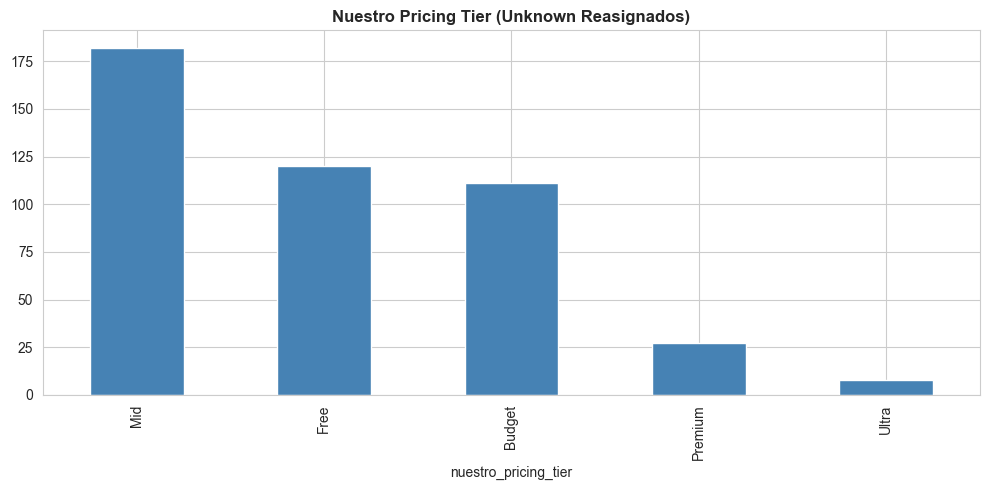

In [7]:
# Reasignar Unknown basado en cluster más similar
df_limpio['nuestro_pricing_tier'] = df_limpio['pricing_tier'].copy()

for idx, row in df_limpio[df_limpio['pricing_tier'] == 'Unknown'].iterrows():
    cluster_id = row['cluster']
    cluster_data = df_limpio[(df_limpio['cluster'] == cluster_id) & (df_limpio['pricing_tier'] != 'Unknown')]
    
    if len(cluster_data) > 0:
        # Asignar la categoría más frecuente en ese cluster
        most_common = cluster_data['pricing_tier'].mode()
        if len(most_common) > 0:
            df_limpio.loc[idx, 'nuestro_pricing_tier'] = most_common[0]
        else:
            # Si no hay, asignar basado en inteligencia
            intel = row['aa_intelligence_index']
            if intel < 30:
                df_limpio.loc[idx, 'nuestro_pricing_tier'] = 'Budget'
            elif intel < 50:
                df_limpio.loc[idx, 'nuestro_pricing_tier'] = 'Mid'
            elif intel < 70:
                df_limpio.loc[idx, 'nuestro_pricing_tier'] = 'Premium'
            else:
                df_limpio.loc[idx, 'nuestro_pricing_tier'] = 'Ultra'

print('Distribución después de reasignar Unknown:')
print(df_limpio['nuestro_pricing_tier'].value_counts())

fig, ax = plt.subplots(figsize=(10, 5))
df_limpio['nuestro_pricing_tier'].value_counts().plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Nuestro Pricing Tier (Unknown Reasignados)', fontweight='bold')
plt.tight_layout()
plt.savefig('../results/plots/02_nuestro_pricing_tier.png', dpi=300, bbox_inches='tight')
plt.show()

**Resultado de la reasignación (134 modelos Unknown):**

| Categoría asignada | Cantidad | % de Unknown |
|-------------------|----------|--------------|
| Free              | 104      | 77.6%        |
| Mid               | 30       | 22.4%        |

**Distribución final (`nuestro_pricing_tier`):**

| Tier | Antes (oficial) | Después (nuestro) |
|------|-----------------|-------------------|
| Mid     | 152 | 182 |
| Free    | 16  | 120 |
| Budget  | 111 | 111 |
| Premium | 27  | 27  |
| Ultra   | 8   | 8   |
| Unknown | 138 | **0** |

> La mayoría de los Unknown (77.6%) son técnicamente similares a modelos `Free`, lo que sugiere que son modelos open source o experimentales sin precio asignado en el dataset original

## Visualización PCA: Clusters y Pricing Tier

Se aplica PCA (2 componentes) para proyectar el espacio de 10 features en 2 dimensiones y visualizar la separación de clusters.

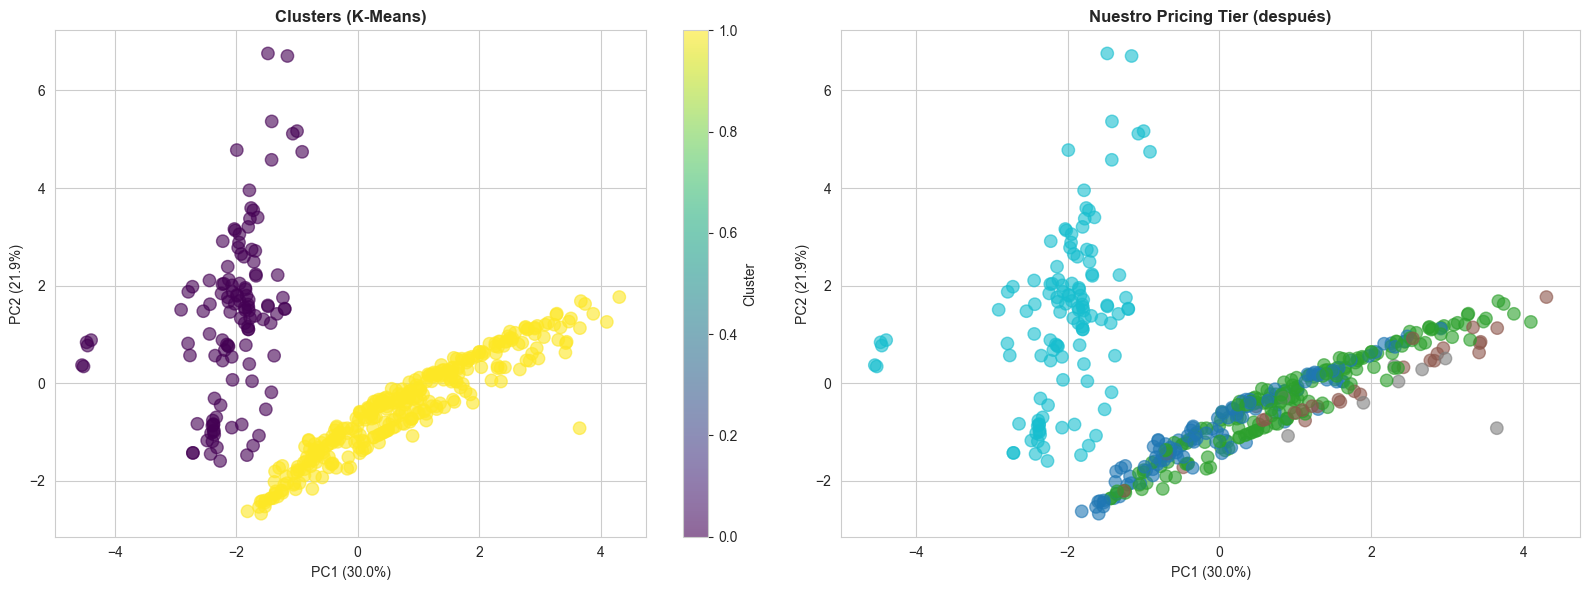

In [9]:
# PCA visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_escalado)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Por cluster
scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=df_limpio['cluster'], cmap='viridis', s=80, alpha=0.6)
axes[0].set_title('Clusters (K-Means)', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# Por nuestro pricing tier
tier_map = {'Budget': 0, 'Mid': 1, 'Premium': 2, 'Ultra': 3, 'Free': 4}
df_limpio['tier_color'] = df_limpio['nuestro_pricing_tier'].map(tier_map)
scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=df_limpio['tier_color'], cmap='tab10', s=80, alpha=0.6)
axes[1].set_title('Nuestro Pricing Tier (después)', fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')

plt.tight_layout()
plt.savefig('../results/plots/02_clusters_y_tier.png', dpi=300, bbox_inches='tight')
plt.show()

La visualización muestra dos gráficos:
- **Izquierda:** coloreado por cluster K-Means (0 = Económico, 1 = Premium)
- **Derecho:** coloreado por `nuestro_pricing_tier` reasignado

> Una buena separación visual en el espacio PCA confirma que los clusters tienen coherencia estadística y que la reasignación de Unknown es metodológicamente válida.

## Modelo 1: Random Forest Classifier

Se entrena un Random Forest con el target `nuestro_pricing_tier` (sin modelos Unknown).

In [10]:
# Entrenar modelos con nuestro_pricing_tier
X_train, X_test, y_train, y_test = train_test_split(
    X, df_limpio['nuestro_pricing_tier'], test_size=0.2, random_state=42, stratify=df_limpio['nuestro_pricing_tier']
)

rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print('RANDOM FOREST')
print(f'Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}')
print(classification_report(y_test, y_pred_rf))

RANDOM FOREST
Accuracy: 0.9889
              precision    recall  f1-score   support

      Budget       1.00      1.00      1.00        22
        Free       1.00      1.00      1.00        24
         Mid       0.97      1.00      0.99        37
     Premium       1.00      0.80      0.89         5
       Ultra       1.00      1.00      1.00         2

    accuracy                           0.99        90
   macro avg       0.99      0.96      0.98        90
weighted avg       0.99      0.99      0.99        90



**Configuración:**
- `n_estimators = 100`, `max_depth = 10`, `random_state = 42`
- Split: 80% train / 20% test con `stratify=y`

**Resultados:**

| Clase   | Precision | Recall | F1   | Support |
|---------|-----------|--------|------|---------|
| Budget  | 1.00      | 1.00   | 1.00 | 22      |
| Free    | 1.00      | 1.00   | 1.00 | 24      |
| Mid     | 0.97      | 1.00   | 0.99 | 37      |
| Premium | 1.00      | 0.80   | 0.89 | 5       |
| Ultra   | 1.00      | 1.00   | 1.00 | 2       |

**Accuracy: 0.9889 (98.89%)**

## Modelo 2: Gradient Boosting Classifier

Se entrena Gradient Boosting con los mismos datos y split para comparación directa.

In [11]:
gb_model = GradientBoostingClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

print('GRADIENT BOOSTING')
print(f'Accuracy: {accuracy_score(y_test, y_pred_gb):.4f}')
print(classification_report(y_test, y_pred_gb))

GRADIENT BOOSTING
Accuracy: 0.9889
              precision    recall  f1-score   support

      Budget       1.00      1.00      1.00        22
        Free       1.00      1.00      1.00        24
         Mid       0.97      1.00      0.99        37
     Premium       1.00      0.80      0.89         5
       Ultra       1.00      1.00      1.00         2

    accuracy                           0.99        90
   macro avg       0.99      0.96      0.98        90
weighted avg       0.99      0.99      0.99        90



**Configuración:**
- `n_estimators = 100`, `max_depth = 5`, `learning_rate = 0.1`, `random_state = 42`

**Resultados:**

| Clase   | Precision | Recall | F1   | Support |
|---------|-----------|--------|------|---------|
| Budget  | 1.00      | 1.00   | 1.00 | 22      |
| Free    | 1.00      | 1.00   | 1.00 | 24      |
| Mid     | 0.97      | 1.00   | 0.99 | 37      |
| Premium | 1.00      | 0.80   | 0.89 | 5       |
| Ultra   | 1.00      | 1.00   | 1.00 | 2       |

**Accuracy: 0.9889 (98.89%)**

## Conclusión — Notebook 02

| Modelo | Accuracy |
|--------|----------|
| Random Forest | 0.9889 |
| Gradient Boosting | 0.9889 |

Ambos modelos alcanzan **98.89% de accuracy** en la predicción del `nuestro_pricing_tier`.

**Interpretación:** El alto accuracy refleja que los clusters técnicos descubiertos generan fronteras de decisión muy nítidas. La única confusión ocurre en **1 modelo Premium clasificado como Mid**, lo cual es razonable dado que Premium y Mid son las categorías con mayor superposición de características técnicas.